## 1. What this notebook computes

At zero 3-momentum the free Kohn-Sham spectrum of dirac16complex contains eight
zero modes ($\varepsilon = 0$) sitting at the brane. This notebook follows what
happens when the 3-momentum $k$ is switched on, at the five slices
$a_{4,0} = 0, 0.5, 1, 1.5, 2$ of the PRESCRIBED deflating history. It

- computes the BRANE BAND (the level that grows out of the zero modes) and three
  other low levels for $k$ from 0 to 4 and reproduces the Rust solver's record
  (figure 1);
- derives the slope $c = d\varepsilon/dk$ at $k = 0$ with the Hellmann-Feynman
  rule, $c = e^{-a_{4,0}}\,\frac{2M}{2M - H}\,\frac{1 - e^{-(2M-H)L}}
  {1 - e^{-2ML}}$, and checks it numerically at every slice (figure 2);
- checks the exact rescaling identity $\varepsilon(k, a_{4,0}) =
  \varepsilon(k\,e^{-a_{4,0}}, 0)$: along the history the band is redshifted
  (figure 3);
- checks the mirror symmetries of the two block types $j = \pm1$ (figure 4);
- shows that the band does not feel the tip condition (figure 5);
- finds the particle branch, the degeneracies $4r_3(n^2)$ of the torus lattice
  and the closed shells of the free aufbau, with the particle numbers
  $N = 8, 136, 688$ of the Revision runs (figure 6).

It prints a PASS line for every check (15 in all) and saves six figures.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 14c (The brane band: free Kohn-Sham levels at nonzero 3-momentum along the
deflating history) is the file `Revision/textbook/notebooks/14c_brane_band.ipynb` of the
repository Dirac_claude. With the fourth-order Runge-Kutta shooting method of the
Revision Rust solver it computes the free Kohn-Sham levels of dirac16complex at nonzero
3-momentum k: the brane band that grows out of the zero modes, its slope c at k = 0 from
the Hellmann-Feynman rule and its exact formula, the redshift of the band along the
prescribed deflating history and the exact rescaling identity eps(k, a4) = eps(k e^(-a4),
0), the mirror symmetries of the two block types, the insensitivity of the band to the
tip condition, the particle branch, the lattice degeneracies 4 r3(n2) and the closed
shells of the free aufbau with the particle numbers 8, 136 and 688; it reproduces the
Revision Rust solver's records of all of these and draws six teaching figures. It needs a
computer with Windows 11, macOS or Linux, an internet connection for the installation,
the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
and nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 14c_brane_band.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 2 minutes on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 14c_brane_band.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
14c_brane_band.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:
`Revision/textbook/figures/14c.captions.json`,
`Revision/textbook/figures/14c_1_band_structure.png`,
`Revision/textbook/figures/14c_2_band_slope.png`,
`Revision/textbook/figures/14c_3_band_redshift.png`,
`Revision/textbook/figures/14c_4_block_type_mirror.png`,
`Revision/textbook/figures/14c_5_tip_insensitivity.png` and
`Revision/textbook/figures/14c_6_closed_shells.png`. It changes no other file of the
repository; running it headless or saving it in JupyterLab also rewrites the notebook
file itself. It does not use the internet while it runs. The files it writes are the same
files that are stored in the repository (on another computer a figure may differ in a few
bytes, which is harmless). To get the stored versions back, run this command in the
repository folder (it also undoes every change you made yourself in the folder
Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all six figure files of this notebook exist
    ALL 15 CHECKS PASSED (notebook 14c)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/14c_brane_band.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- the cells of sections 8 and 11 run for 10 to 20 seconds each: they integrate the
  equation for hundreds of energies at once, 72 times over; wait until the PASS lines
  appear.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 14c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 14c (The brane band: free Kohn-Sham levels at nonzero 3-momentum along the
# deflating history) is the file Revision/textbook/notebooks/14c_brane_band.ipynb of the
# repository Dirac_claude. With the fourth-order Runge-Kutta shooting method of the
# Revision Rust solver it computes the free Kohn-Sham levels of dirac16complex at nonzero
# 3-momentum k: the brane band that grows out of the zero modes, its slope c at k = 0
# from the Hellmann-Feynman rule and its exact formula, the redshift of the band along
# the prescribed deflating history and the exact rescaling identity eps(k, a4) = eps(k
# e^(-a4), 0), the mirror symmetries of the two block types, the insensitivity of the
# band to the tip condition, the particle branch, the lattice degeneracies 4 r3(n2) and
# the closed shells of the free aufbau with the particle numbers 8, 136 and 688; it
# reproduces the Revision Rust solver's records of all of these and draws six teaching
# figures. It needs a computer with Windows 11, macOS or Linux, an internet connection
# for the installation, the program Git, and Python 3.12 or newer (the notebooks were
# built with Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6,
# sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
# nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports
# numpy, sympy and matplotlib; the other packages run Jupyter, the program that shows and
# runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 14c_brane_band.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 2
# minutes on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 14c_brane_band.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 14c_brane_band.ipynb (in the same folder, without running the cells again) to read the
# printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
# Revision/textbook/figures/14c.captions.json,
# Revision/textbook/figures/14c_1_band_structure.png,
# Revision/textbook/figures/14c_2_band_slope.png,
# Revision/textbook/figures/14c_3_band_redshift.png,
# Revision/textbook/figures/14c_4_block_type_mirror.png,
# Revision/textbook/figures/14c_5_tip_insensitivity.png and
# Revision/textbook/figures/14c_6_closed_shells.png. It changes no other file of the
# repository; running it headless or saving it in JupyterLab also rewrites the notebook
# file itself. It does not use the internet while it runs. The files it writes are the
# same files that are stored in the repository (on another computer a figure may differ
# in a few bytes, which is harmless). To get the stored versions back, run this command
# in the repository folder (it also undoes every change you made yourself in the folder
# Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all six figure files of this notebook exist
#     ALL 15 CHECKS PASSED (notebook 14c)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/14c_brane_band.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - the cells of sections 8 and 11 run for 10 to 20 seconds each: they integrate the
#   equation for hundreds of energies at once, 72 times over; wait until the PASS lines
#   appear.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "14c"  # this notebook: chapter 14, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 14c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Level, orbital, label**: an energy $\varepsilon$ of the block equation
  $h_j\chi = \varepsilon\chi$, its solution, and the integer that counts its
  Pruefer half-turns (even parity: $\Phi = l\pi$, odd: $\Phi = \pi/2 + l\pi$).
- **3-momentum $k$**: the momentum along ordinary 3-space; on the coordinate
  torus of size $\ell$ the allowed vectors are $\Delta k\,(n_1, n_2, n_3)$ with
  integers $n_i$ and $\Delta k = 2\pi/\ell = 0.25$ (in units of $H$).
- **Shell**: all lattice vectors with the same $n^2 = n_1^2 + n_2^2 + n_3^2$;
  $r_3(n^2)$ is their number (for example $r_3(1) = 6$).
- **Brane band**: the even-parity level of label 0 in the blocks $j = +1$, which
  is the zero mode at $k = 0$ and rises with $k$.
- **Slope $c$**: $d\varepsilon/dk$ of the brane band at $k = 0$.
- **Hellmann-Feynman rule**: for a normalised eigenvector, the derivative of
  the level is the expectation value of the derivative of the Hamiltonian:
  $d\varepsilon/dk = \langle\chi|\,\partial h/\partial k\,|\chi\rangle$.
- **Slice, history**: the slice $a_{4,0}$ is the value of $a_4$ at one instant;
  the history $a_4 = AHx_4$ is a PRESCRIBED BACKGROUND (given, not solved for).
- **Redshift**: a 3-momentum $k$ acts like $k\,e^{-a_{4,0}}$ at the slice
  $a_{4,0}$: momenta shrink as 3-space inflates.
- **Tip condition**: the condition $(1 - Q(\theta))\chi(-L) = 0$ at the cutoff
  $y = -L$; $\theta = 0$ ($b(-L) = 0$) is the canonical choice.
- **Particle branch, sea**: by a CONVENTION of the Revision theory, the levels
  that are positive in the free problem (and the $k = 0$ zero modes) are
  particle levels; the negative branch is the filled, normal-ordered sea.
- **Aufbau, closed shell**: fill the $N$ lowest particle states; $N$ is a closed
  shell when the filling ends exactly at the end of a degenerate group of levels.
- **Bulk edge**: the lowest level that is not on the brane band (here a $k = 0$
  level of the odd parity).
- **Richardson extrapolation**: combining two finite-difference estimates so that
  their leading errors cancel.

## 4. The physical and mathematical situation

In each $2\times2$ block of type $j$ the free Kohn-Sham equation is
$h_j\chi = \varepsilon\chi$ with $h_j = j[-i\sigma_1\,d/dy + M\sigma_2 +
\kappa(y)k\,\sigma_3]$, the momentum weight $\kappa(y) = e^{-Hy - a_{4,0}}$, the
ASSUMED Z2 mirror brane at $y = 0$ (even: $b(0) = 0$, odd: $a(0) = 0$) and the
regular tip $b(-L) = 0$ at the cutoff $y = -L$; in real form $\chi = (a, ib)$:
$a' = Ma - (\kappa k + j\varepsilon)b$, $b' = (j\varepsilon - \kappa k)a - Mb$.

The momentum term $\kappa k\sigma_3$ pushes the orbitals toward the brane
($\kappa$ grows toward the tip) and lifts the zero modes into a band. Every level
holds $4r_3(n^2)$ states for each block type (four blocks times the number of
lattice directions of the shell). The canonical parameters of the Revision
solver are $H = m = 1$, $L = 3$, $\Delta k = 0.25$, the slices $a_{4,0} = 0,
0.5, 1, 1.5, 2$, and RK4 with $G = 900$ steps.

Status: the slope formula and the rescaling identity are PROVED (exact); the
numerical levels are COMPUTED (they reproduce the Rust solver's records); the
brane condition is ASSUMED; the tip condition is a chosen cutoff condition; the
history is a PRESCRIBED BACKGROUND; the counting of the zero modes as particles
is a CONVENTION whose justification is OPEN.

## 5. The shooting tools

The next cell defines the numerical tools, exactly the method of the Revision
Rust solver: `shoot` integrates the real form from the tip ($(a, b) =
(\cos\frac\theta2, \sin\frac\theta2)$, canonical $\theta = 0$) to the brane with
classical RK4 ($G$ steps; the coefficients at the nodes and step midpoints of a
fine grid of $2G + 1$ points) and follows the Pruefer angle $\mathrm{atan2}(b, a)$
step by step; it returns $\Phi = j\,\theta(0)$, which grows strictly with
$\varepsilon$. `levels` finds the energy with $\Phi = $ target (even $l\pi$, odd
$\pi/2 + l\pi$) by 72 bisections of $[-20, 20]$. `orbital` returns a normalised
orbital on the fine grid (cubic Hermite values at the midpoints, Simpson's rule
for the norm). All three accept arrays (numpy), so that hundreds of levels are
found at once. It also reads the Rust solver's records with a small CSV reader
and defines `record_check`, which reads the verdict of a named check.

In [2]:
import math  # exp, cos, sin of single numbers

import numpy as np  # floating-point arrays
import sympy as sp  # exact algebra with symbols

RUST_REPORT = "Revision/kohn_sham/reports/ks-rust-solver.json"
SPECTRUM = "Revision/kohn_sham/results/spectrum"  # the folder of the records


def record_check(name, report=RUST_REPORT):
    """The check called name is PASS in the Revision report."""
    data = json.loads(repository_file(report).read_text(encoding="utf-8"))
    return [c["verdict"] for c in data["checks"] if c["name"] == name] == ["PASS"]


def read_csv(relative):
    """The rows of a CSV record as a list of dictionaries (column -> text)."""
    lines = repository_file(relative).read_text(encoding="utf-8").splitlines()
    header = lines[0].split(",")
    return [dict(zip(header, line.split(","))) for line in lines[1:]]


def shoot(eps, k=0.0, j=1.0, a4=0.0, M=1.0, L=3.0, G=900, H=1.0, tip=0.0,
          keep=False):
    """Phi = j theta(0) for the energies eps (arrays allowed for eps, k, j, a4);
    with keep=True also theta, a, b at the G + 1 nodes."""
    eps, k, j, a4 = np.broadcast_arrays(*(np.asarray(x, dtype=float)
                                          for x in (eps, k, j, a4)))
    nf = 2 * G + 1  # nodes and step midpoints
    y_fine = -L * ((nf - 1 - np.arange(nf)) / (nf - 1))
    e_minus_Hy = np.exp(-H * y_fine)
    kk = k * np.exp(-a4)  # kappa k = kk e^(-Hy)
    h = L / G
    a_ = np.full(eps.shape, math.cos(0.5 * tip))
    b_ = np.full(eps.shape, math.sin(0.5 * tip))
    theta = np.full(eps.shape, 0.5 * tip)
    raw = np.arctan2(b_, a_)
    je = j * eps
    path = [(theta, a_, b_)]
    for i in range(G):
        K0, K1, K2 = (kk * e_minus_Hy[2 * i], kk * e_minus_Hy[2 * i + 1],
                      kk * e_minus_Hy[2 * i + 2])
        p1a, p1b = M * a_ - (K0 + je) * b_, (je - K0) * a_ - M * b_
        a2, b2 = a_ + 0.5 * h * p1a, b_ + 0.5 * h * p1b
        p2a, p2b = M * a2 - (K1 + je) * b2, (je - K1) * a2 - M * b2
        a3, b3 = a_ + 0.5 * h * p2a, b_ + 0.5 * h * p2b
        p3a, p3b = M * a3 - (K1 + je) * b3, (je - K1) * a3 - M * b3
        a4_, b4_ = a_ + h * p3a, b_ + h * p3b
        p4a, p4b = M * a4_ - (K2 + je) * b4_, (je - K2) * a4_ - M * b4_
        a_ = a_ + h / 6.0 * (p1a + 2.0 * p2a + 2.0 * p3a + p4a)
        b_ = b_ + h / 6.0 * (p1b + 2.0 * p2b + 2.0 * p3b + p4b)
        new = np.arctan2(b_, a_)
        step = new - raw  # brought into (-pi, pi]
        step = np.where(step > np.pi, step - 2 * np.pi,
                        np.where(step <= -np.pi, step + 2 * np.pi, step))
        theta = theta + step
        raw = new
        if keep:
            path.append((theta, a_, b_))
    if keep:
        return j * theta, [np.array(q) for q in zip(*path)]
    return j * theta


def target(parity, label):
    offset = np.where(np.asarray(parity) == "even", 0.0, 0.5 * np.pi)
    return offset + np.asarray(label, dtype=float) * np.pi


def levels(k, j, parity, label, a4=0.0, iterations=72, **options):
    """The levels with these labels (arrays allowed), by bisection."""
    k, j, parity, label, a4 = np.broadcast_arrays(
        np.asarray(k, dtype=float), np.asarray(j, dtype=float), np.asarray(parity),
        np.asarray(label), np.asarray(a4, dtype=float))
    goal = target(parity, label)
    lo, hi = np.full(k.shape, -20.0), np.full(k.shape, 20.0)
    for _ in range(iterations):
        mid = 0.5 * (lo + hi)
        g = shoot(mid, k, j, a4, **options) - goal
        lo = np.where(g <= 0.0, mid, lo)
        hi = np.where(g >= 0.0, mid, hi)
    return 0.5 * (lo + hi)


def orbital(eps, k=0.0, j=1.0, a4=0.0, M=1.0, L=3.0, G=900, H=1.0):
    """The normalised orbital (y, a, b) and the Simpson weights on the fine grid."""
    _, (_, a_n, b_n) = shoot(eps, k, j, a4, M=M, L=L, G=G, H=H, keep=True)
    nf, h = 2 * G + 1, L / G
    y_fine = -L * ((nf - 1 - np.arange(nf)) / (nf - 1))
    K_fine = k * math.exp(-a4) * np.exp(-H * y_fine)
    a_f, b_f = np.zeros(nf), np.zeros(nf)
    a_f[0::2], b_f[0::2] = a_n, b_n
    da = M * a_f - (K_fine + j * eps) * b_f
    db = (j * eps - K_fine) * a_f - M * b_f
    for f in range(1, nf, 2):  # cubic Hermite values at the midpoints
        a_f[f] = 0.5 * (a_f[f - 1] + a_f[f + 1]) + h / 8.0 * (da[f - 1] - da[f + 1])
        b_f[f] = 0.5 * (b_f[f - 1] + b_f[f + 1]) + h / 8.0 * (db[f - 1] - db[f + 1])
    weights = np.full(nf, 2.0)  # Simpson weights 1, 4, 2, ..., 4, 1 times (h/2)/3
    weights[1::2] = 4.0
    weights[0] = weights[-1] = 1.0
    weights *= 0.5 * h / 3.0
    norm = math.sqrt(float(np.sum(weights * (a_f ** 2 + b_f ** 2))))
    return y_fine, a_f / norm, b_f / norm, weights


SLICES = [0.0, 0.5, 1.0, 1.5, 2.0]  # the slices of the Revision solver
say("defined: shoot, levels, orbital, read_csv, record_check")

defined: shoot, levels, orbital, read_csv, record_check


## 6. The brane band and three other levels for k from 0 to 4

The Rust solver's record `brane-band.csv` lists, for $k = 0, 0.05, 0.10, \dots,
4$ at the slice $a_{4,0} = 0$, the brane band (block type $j = +1$, even, label
0), the next even level of $j = +1$ (label 1), the lowest odd level of $j = +1$
(label 0), and the even level of label 1 in the blocks $j = -1$. The next cell
computes these $4\times81$ levels in one call (and, for the figure, the brane
band of the blocks $j = -1$, label 0), and checks that they equal the record to
$10^{-11}$. The $k$ values are made exactly as in the Rust program, by adding
0.05 again and again (so that the last digits agree). It also checks that the
band rises strictly with $k$.

In [3]:
k_list, kk = [], 0.0
while kk <= 4.0 + 1e-12:  # 0, 0.05, 0.10, ... as the Rust program makes them
    k_list.append(kk)
    kk += 0.05
k_band = np.array(k_list)
sectors = [(1.0, "even", 0), (1.0, "even", 1), (1.0, "odd", 0), (-1.0, "even", 1),
           (-1.0, "even", 0)]  # (j, parity, label); the last one for the figure
K_all = np.concatenate([k_band] * len(sectors))
J_all = np.concatenate([[j_] * len(k_band) for j_, _, _ in sectors])
P_all = np.concatenate([[p_] * len(k_band) for _, p_, _ in sectors])
L_all = np.concatenate([[l_] * len(k_band) for _, _, l_ in sectors])
found = levels(K_all, J_all, P_all, L_all).reshape(len(sectors), len(k_band))
band, bulk_even, odd0, minus_even1, minus_band = found
rows = read_csv(f"{SPECTRUM}/brane-band.csv")
record = np.array([[float(r[c]) for r in rows] for c in
                   ("eps_band_a0", "eps_band_bulk_even_l1", "eps_odd_l0",
                    "eps_jm1_even_l1")])
k_record = np.array([float(r["k"]) for r in rows])
say(f"k = 0.25: brane band {band[5]:.10f}, odd level {odd0[5]:.10f} (units of m)")
check(len(rows) == 81 and np.max(np.abs(k_record - k_band)) < 1e-15
      and np.max(np.abs(found[:4] - record)) < 1e-11,
      "the 324 levels equal the record brane-band.csv",
      record=f"{SPECTRUM}/brane-band.csv")
check(bool(np.all(np.diff(band) > 0.0)) and np.max(np.abs(minus_band + band)) < 1e-12,
      "the band rises strictly with k; the j = -1 band is its mirror image -eps")

k = 0.25: brane band 0.4307336786, odd level 1.9195133815 (units of m)
PASS the 324 levels equal the record brane-band.csv
     reproduces Revision/kohn_sham/results/spectrum/brane-band.csv
PASS the band rises strictly with k; the j = -1 band is its mirror image -eps


The next cell draws the band structure: the five levels against $k$, with the
straight line $c\,k$ of the first-order slope (section 7) and the bulk edge
$1.2923\,m$ (the lowest odd level at $k = 0$, the lowest level not on the band).

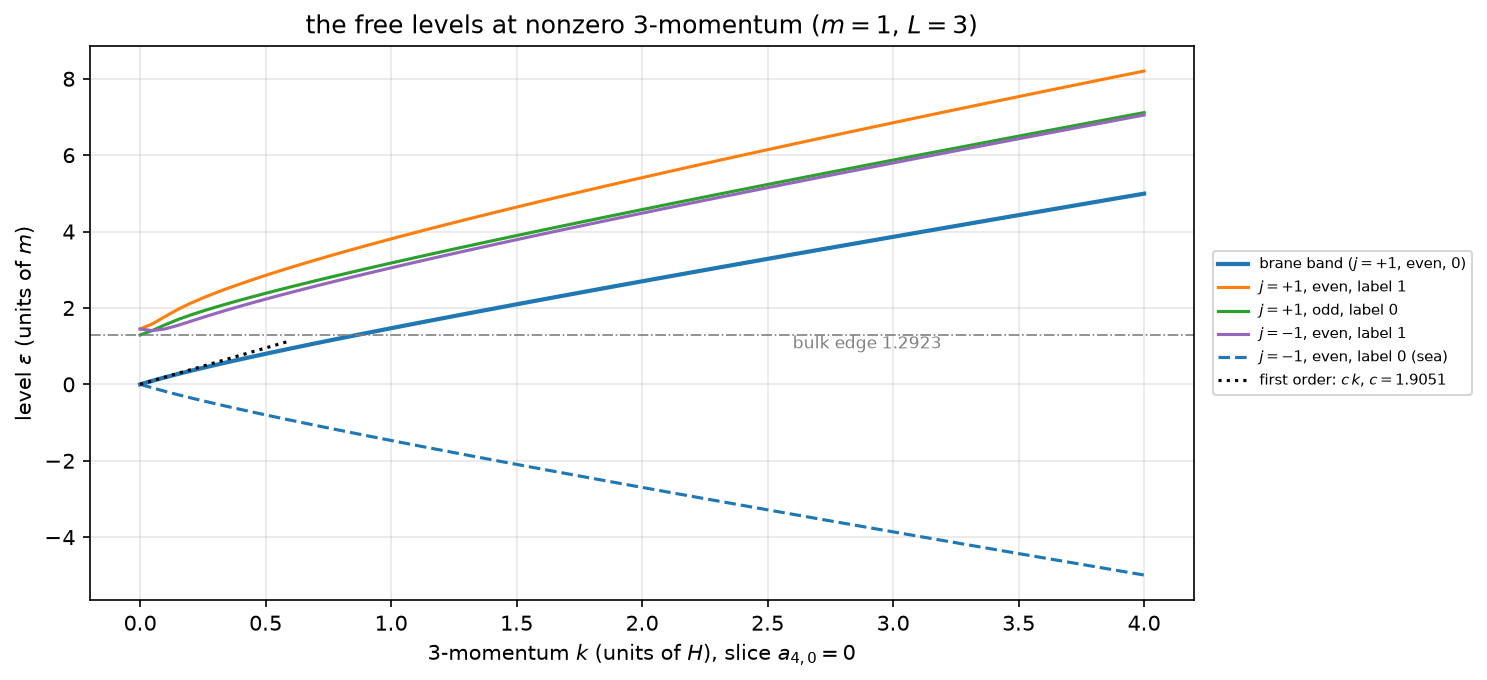

Figure 14c.1 saved as Revision/textbook/figures/14c_1_band_structure.png


In [4]:
c_theory = 2.0 / (1.0 + math.exp(-3.0))  # the slope for M = H = 1, L = 3, a4,0 = 0
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(k_band, band, color="C0", linewidth=2, label="brane band ($j = +1$, even, 0)")
ax.plot(k_band, bulk_even, color="C1", label="$j = +1$, even, label 1")
ax.plot(k_band, odd0, color="C2", label="$j = +1$, odd, label 0")
ax.plot(k_band, minus_even1, color="C4", label="$j = -1$, even, label 1")
ax.plot(k_band, minus_band, "--", color="C0",
        label="$j = -1$, even, label 0 (sea)")
ax.plot(k_band[:13], c_theory * k_band[:13], ":", color="black",
        label="first order: $c\\,k$, $c = 1.9051$")
ax.axhline(odd0[0], color="gray", linewidth=0.8, linestyle="-.")
ax.annotate("bulk edge 1.2923", (2.6, odd0[0] - 0.35), fontsize=8, color="gray")
ax.set_xlabel("3-momentum $k$ (units of $H$), slice $a_{4,0} = 0$")
ax.set_ylabel("level $\\varepsilon$ (units of $m$)")
ax.set_title("the free levels at nonzero 3-momentum ($m = 1$, $L = 3$)")
ax.legend(fontsize=7, loc="center left", bbox_to_anchor=(1.01, 0.5))
save_figure(fig, "band_structure",
            "The free Kohn-Sham levels against the 3-momentum $k$ (units of "
            "$H$) at the slice $a_{4,0} = 0$ for $m = 1$, $L = 3$; vertical axis "
            "the level in units of $m$. The brane band (thick) starts at the zero "
            "mode and rises with the slope $c = 1.9051$ (dotted line) and then "
            "more slowly; the bulk levels start above the bulk edge "
            "$1.2923\\,m$ (dash-dotted); the dashed curve is the brane band of "
            "the blocks $j = -1$, the mirror image $-\\varepsilon$, which belongs "
            "to the sea.")

## 7. The slope of the band at k = 0: the Hellmann-Feynman rule

Line by line:

1. If $h(k)\chi = \varepsilon(k)\chi$ with $\int\chi^\dagger\chi\,dy = 1$ and
   boundary conditions that do not depend on $k$, then $\varepsilon =
   \int\chi^\dagger h\chi\,dy$, and differentiating, the terms with
   $d\chi/dk$ add up to $\varepsilon\,\frac{d}{dk}\int\chi^\dagger\chi\,dy = 0$
   ($h$ is self-adjoint): $d\varepsilon/dk = \int\chi^\dagger(\partial_k h)\chi
   \,dy$.
2. Here $\partial_k h_j = j\kappa(y)\sigma_3$ and, at $k = 0$, $\chi$ is the zero
   mode $(a, 0)$ with $a^2 \propto e^{2My}$, so $\chi^\dagger\sigma_3\chi = a^2$.
3. Hence $d\varepsilon/dk = jc$ with
   $c = \int_{-L}^0 e^{-Hy - a_{4,0}}e^{2My}\,dy\,/\int_{-L}^0 e^{2My}\,dy$.
4. Doing the two integrals: $c = e^{-a_{4,0}}\,\frac{2M}{2M - H}\,
   \frac{1 - e^{-(2M - H)L}}{1 - e^{-2ML}}$; for $M = H = 1$:
   $c = e^{-a_{4,0}}\,\frac{2(1 - e^{-L})}{1 - e^{-2L}} = \frac{2e^{-a_{4,0}}}
   {1 + e^{-L}}$, which is $1.9051482536$ for $L = 3$, $a_{4,0} = 0$.

The next cell does step 4 with sympy, compares the value with the Revision
record (`checksNumeric.braneBandSlope_M1_H1_L3_a0` of ks-theory.json), computes
the integral of step 3 numerically from the zero-mode orbital (Simpson), and
measures the slope numerically at the five slices as the Rust solver did:
levels at $k = 10^{-4}$ and $2\times10^{-4}$, and the Richardson combination
$c = (4\varepsilon_1/10^{-4} - \varepsilon_2/(2\times10^{-4}))/3$, which removes
the $k^2$ error of $\varepsilon/k$. These must equal the record
`brane-band-slope.csv`. Finally it measures the slope for $L = 2$ and $L = 4$.

In [5]:
Ms, Hs, Ls = sp.symbols("M H L", positive=True)
ys, a4s = sp.symbols("y a", real=True)
ratio = (sp.integrate(sp.exp(-Hs * ys - a4s) * sp.exp(2 * Ms * ys), (ys, -Ls, 0))
         / sp.integrate(sp.exp(2 * Ms * ys), (ys, -Ls, 0)))  # step 3
formula = (sp.exp(-a4s) * 2 * Ms / (2 * Ms - Hs) * (1 - sp.exp(-(2 * Ms - Hs) * Ls))
           / (1 - sp.exp(-2 * Ms * Ls)))  # step 4
same = sp.simplify((ratio - formula).subs({Ms: 1, Hs: 1, Ls: 3})) == 0 and \
    sp.simplify((ratio - formula).subs({Ms: 2, Hs: 1, Ls: 3})) == 0
c_exact = float(formula.subs({Ms: 1, Hs: 1, Ls: 3, a4s: 0}))
theory = json.loads(repository_file("Revision/kohn_sham/ks-theory.json")
                    .read_text(encoding="utf-8"))
c_record = float(theory["checksNumeric"]["braneBandSlope_M1_H1_L3_a0"])
report("slope c for M = H = 1, L = 3, a4,0 = 0", f"{c_exact:.13f}", "m/H")
check(same and abs(c_exact - c_record) < 1e-15 and abs(c_exact - c_theory) < 1e-15
      and record_check("brane_band_slope",
                       "Revision/kohn_sham/reports/ks-theory-python.json"),
      "c = e^(-a4,0) (2M/(2M - H)) (1 - e^(-(2M-H)L))/(1 - e^(-2ML)) = 1.9051482536",
      record="Revision/kohn_sham/ks-theory.json, checksNumeric "
             "braneBandSlope_M1_H1_L3_a0")
y_f, a_zero, b_zero, simpson = orbital(0.0)  # the zero mode at k = 0
c_integral = float(np.sum(simpson * np.exp(-y_f) * a_zero ** 2))  # step 3
check(abs(c_integral - c_exact) < 1e-9,
      "the integral of kappa a^2 over the numerical zero mode gives c")
tiny = np.array([1e-4, 2e-4] * 5)  # two small momenta at each slice
slice_of = np.repeat(SLICES, 2)
small = levels(tiny, 1.0, "even", 0, a4=slice_of).reshape(5, 2)
c_numeric = (4.0 * small[:, 0] / 1e-4 - small[:, 1] / 2e-4) / 3.0
rows = read_csv(f"{SPECTRUM}/brane-band-slope.csv")
c_rows = np.array([float(r["c_numeric"]) for r in rows])
for a_, c_ in zip(SLICES, c_numeric):
    say(f"slice a4,0 = {a_}: c numerical {c_:.12f}, "
        f"c e^(-a4,0) exact {c_exact * math.exp(-a_):.12f}")
check(np.max(np.abs(c_numeric / c_rows - 1.0)) < 1e-11
      and np.max(np.abs(c_numeric / (c_exact * np.exp(-np.array(SLICES))) - 1.0))
      < 1e-9 and record_check("free_brane_band_slope"),
      "the numerical slope equals c e^(-a4,0) at all five slices",
      record=f"{SPECTRUM}/brane-band-slope.csv and {RUST_REPORT}, check "
             "free_brane_band_slope")
c_by_L = {}
for L_ in (2.0, 4.0):  # the slope for two other cutoffs
    pair = levels(np.array([1e-4, 2e-4]), 1.0, "even", 0, L=L_, G=round(300 * L_))
    c_by_L[L_] = (4.0 * pair[0] / 1e-4 - pair[1] / 2e-4) / 3.0
c_by_L[3.0] = float(c_numeric[0])
exact_by_L = {L_: 2.0 / (1.0 + math.exp(-L_)) for L_ in (2.0, 3.0, 4.0)}
say("c for L = 2, 3, 4: " + ", ".join(f"{c_by_L[L_]:.6f}" for L_ in (2.0, 3.0, 4.0))
    + " (exact " + ", ".join(f"{exact_by_L[L_]:.6f}" for L_ in (2.0, 3.0, 4.0)) + ")")
check(all(abs(c_by_L[L_] - exact_by_L[L_]) < 1e-9 for L_ in (2.0, 4.0)),
      "the slope formula holds for L = 2 and L = 4 too")

RESULT slope c for M = H = 1, L = 3, a4,0 = 0 = 1.9051482536449 m/H
PASS c = e^(-a4,0) (2M/(2M - H)) (1 - e^(-(2M-H)L))/(1 - e^(-2ML)) = 1.9051482536
     reproduces Revision/kohn_sham/ks-theory.json, checksNumeric
    braneBandSlope_M1_H1_L3_a0
PASS the integral of kappa a^2 over the numerical zero mode gives c
slice a4,0 = 0.0: c numerical 1.905148253642, c e^(-a4,0) exact 1.905148253645
slice a4,0 = 0.5: c numerical 1.155530827132, c e^(-a4,0) exact 1.155530827134
slice a4,0 = 1.0: c numerical 0.700864874898, c e^(-a4,0) exact 0.700864874900
slice a4,0 = 1.5: c numerical 0.425096034942, c e^(-a4,0) exact 0.425096034942
slice a4,0 = 2.0: c numerical 0.257833778514, c e^(-a4,0) exact 0.257833778515
PASS the numerical slope equals c e^(-a4,0) at all five slices
     reproduces Revision/kohn_sham/results/spectrum/brane-band-slope.csv and
    Revision/kohn_sham/reports/ks-rust-solver.json, check free_brane_band_slope
c for L = 2, 3, 4: 1.761594, 1.905148, 1.964028 (exact 1.761594, 1.9051

The next cell draws the slope. Left: $c$ at the five slices (numerical points)
on the exact curve $c\,e^{-a_{4,0}}$, logarithmic vertical axis. Right: $c$ as a
function of the cutoff $L$ for $a_{4,0} = 0$, with the numerical values for
$L = 2, 3, 4$; for a long hidden interval it approaches $2M/(2M - H) = 2$.

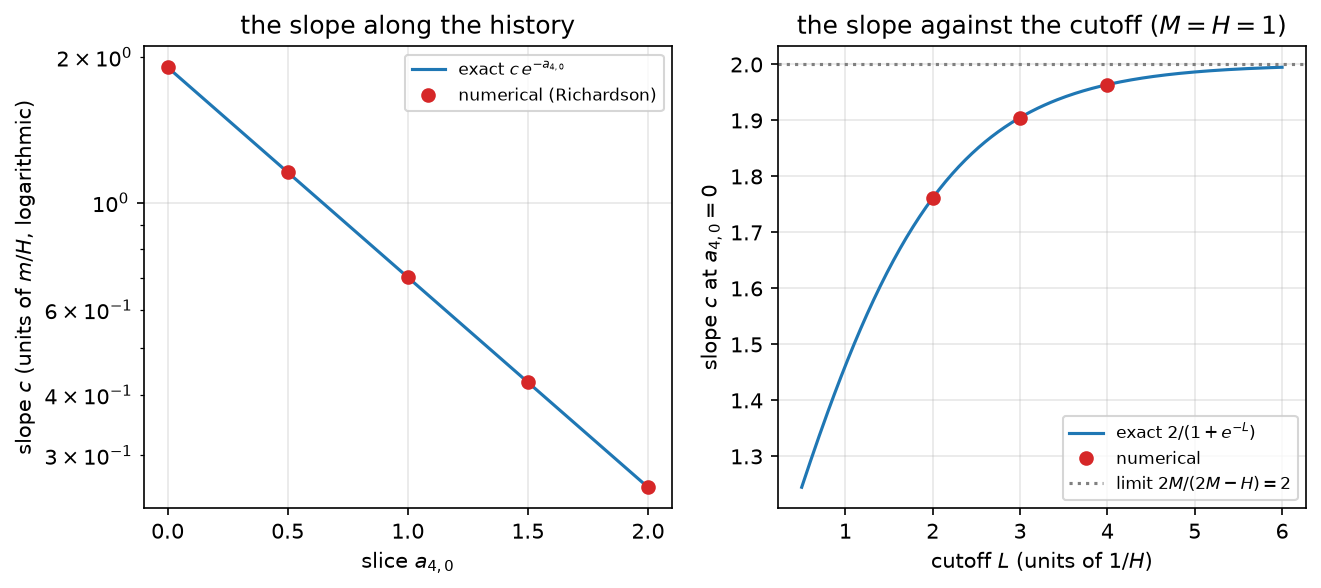

Figure 14c.2 saved as Revision/textbook/figures/14c_2_band_slope.png


In [6]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
a_grid = np.linspace(0.0, 2.0, 201)
left.semilogy(a_grid, c_exact * np.exp(-a_grid), color="C0",
              label="exact $c\\,e^{-a_{4,0}}$")
left.semilogy(SLICES, c_numeric, "o", color="C3", label="numerical (Richardson)")
left.set_xlabel("slice $a_{4,0}$")
left.set_ylabel("slope $c$ (units of $m/H$, logarithmic)")
left.set_title("the slope along the history")
left.legend(fontsize=8)
L_grid = np.linspace(0.5, 6.0, 221)
right.plot(L_grid, 2.0 / (1.0 + np.exp(-L_grid)), color="C0",
           label="exact $2/(1 + e^{-L})$")
right.plot(list(c_by_L), list(c_by_L.values()), "o", color="C3", label="numerical")
right.axhline(2.0, color="gray", linestyle=":", label="limit $2M/(2M - H) = 2$")
right.set_xlabel("cutoff $L$ (units of $1/H$)")
right.set_ylabel("slope $c$ at $a_{4,0} = 0$")
right.set_title("the slope against the cutoff ($M = H = 1$)")
right.legend(fontsize=8)
save_figure(fig, "band_slope",
            "The slope $c = d\\varepsilon/dk$ of the brane band at $k = 0$ "
            "($M = H = 1$). Left: against the slice $a_{4,0}$ from 0 to 2, "
            "logarithmic vertical axis; the numerical Richardson values (dots) lie "
            "on the exact line $c\\,e^{-a_{4,0}}$ with $c = 1.9051$ for $L = 3$: "
            "the band is redshifted along the history. Right: against the "
            "cutoff $L$ (units of $1/H$) at $a_{4,0} = 0$; exact curve "
            "$2/(1 + e^{-L})$ and numerical values for $L = 2, 3, 4$; for a long "
            "hidden interval the slope tends to $2M/(2M - H) = 2$.")

## 8. The deflating history: redshift and the exact rescaling identity

The slice enters the block equation only through $\kappa k = e^{-Hy}(k\,
e^{-a_{4,0}})$, so EXACTLY $\varepsilon(k, a_{4,0}) = \varepsilon(k\,e^{-a_{4,0}},
0)$ for every level. The next cell checks this as the Rust solver did (check
`free_rescaling_relation_and_band_monotone`): for $k = 0.25, 1, 2.5$, the five
slices and three sectors, the level at the slice and the level at slice 0 with
the rescaled momentum agree to $10^{-12}$. It then computes the brane band at
the five slices for the figure, and the gap of the free $N = 8$ state at every
slice: the eight zero modes are filled and the next level is the band at the
first lattice shell $k = \Delta k = 0.25$; this gap must equal the record
`closed-shells.csv` (rows $N = 8$). Along the history the gap shrinks like
$e^{-a_{4,0}}$ for small momenta: $0.4307$, ..., $0.0642\,m$.

In [7]:
test_k = [0.25, 1.0, 2.5]
test_sectors = [(1.0, "even", 0), (1.0, "odd", 0), (-1.0, "even", 1)]
combos = [(a_, k_, s_) for a_ in SLICES for k_ in test_k for s_ in test_sectors]
at_slice = levels(np.array([k_ for a_, k_, s_ in combos]),
                  np.array([s_[0] for a_, k_, s_ in combos]),
                  np.array([s_[1] for a_, k_, s_ in combos]),
                  np.array([s_[2] for a_, k_, s_ in combos]),
                  a4=np.array([a_ for a_, k_, s_ in combos]))
at_zero = levels(np.array([k_ * math.exp(-a_) for a_, k_, s_ in combos]),
                 np.array([s_[0] for a_, k_, s_ in combos]),
                 np.array([s_[1] for a_, k_, s_ in combos]),
                 np.array([s_[2] for a_, k_, s_ in combos]))
check(np.max(np.abs(at_slice - at_zero)) < 1e-12
      and record_check("free_rescaling_relation_and_band_monotone"),
      "eps(k, a4,0) = eps(k e^(-a4,0), 0) for 45 levels at the five slices",
      record=f"{RUST_REPORT}, check free_rescaling_relation_and_band_monotone")
k_fig = np.linspace(0.0, 4.0, 41)
band_slices = levels(np.tile(k_fig, 5), 1.0, "even", 0,
                     a4=np.repeat(SLICES, len(k_fig))).reshape(5, len(k_fig))
gaps = levels(np.full(5, 0.25), 1.0, "even", 0, a4=np.array(SLICES))
shells_record = read_csv(f"{SPECTRUM}/closed-shells.csv")
gap_record = [float(r["gap"]) for r in shells_record if r["N_closed"] == "8"]
for a_, g_ in zip(SLICES, gaps):
    say(f"slice a4,0 = {a_}: gap of the free N = 8 state {g_:.10f} m")
check(len(gap_record) == 5 and np.max(np.abs(gaps - np.array(gap_record))) < 1e-11,
      "the N = 8 gaps at the five slices equal the record",
      record=f"{SPECTRUM}/closed-shells.csv, rows N_closed = 8")

PASS eps(k, a4,0) = eps(k e^(-a4,0), 0) for 45 levels at the five slices
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    free_rescaling_relation_and_band_monotone
slice a4,0 = 0.0: gap of the free N = 8 state 0.4307336786 m
slice a4,0 = 0.5: gap of the free N = 8 state 0.2726448766 m
slice a4,0 = 1.0: gap of the free N = 8 state 0.1703492513 m
slice a4,0 = 1.5: gap of the free N = 8 state 0.1050152416 m
slice a4,0 = 2.0: gap of the free N = 8 state 0.0641594107 m
PASS the N = 8 gaps at the five slices equal the record
     reproduces Revision/kohn_sham/results/spectrum/closed-shells.csv, rows N_closed = 8


The next cell draws the redshift. Left: the brane band against $k$ at the five
slices; later slices lie lower. Right: the same curves against the redshifted
momentum $k\,e^{-a_{4,0}}$: they fall onto one curve, the slice-0 band, which is
the rescaling identity.

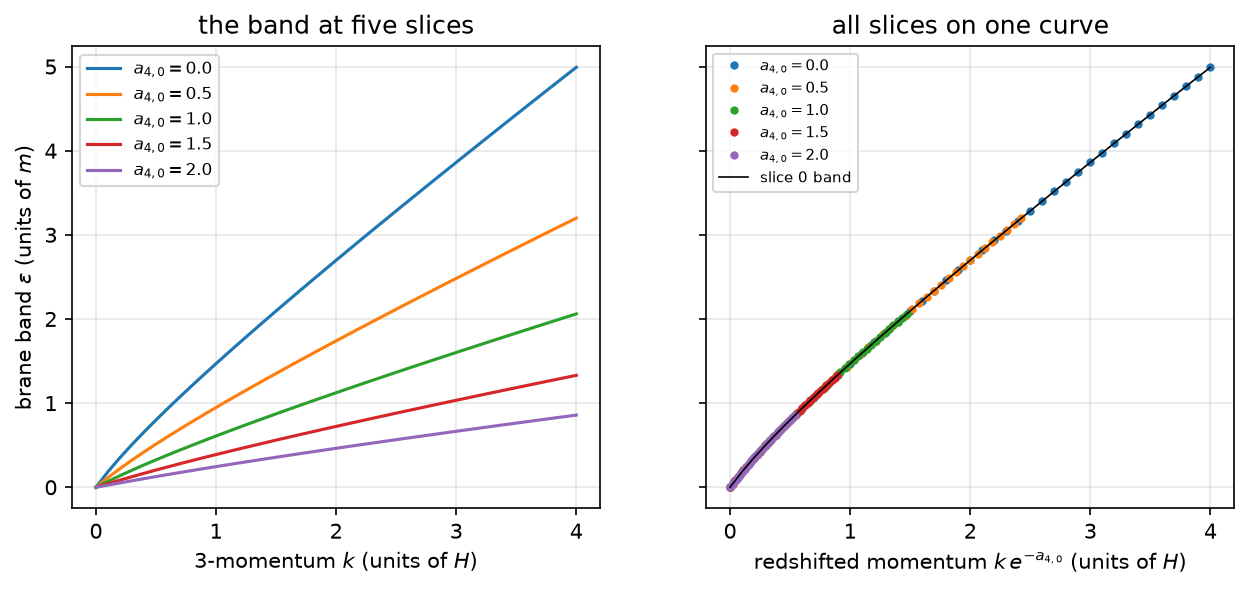

Figure 14c.3 saved as Revision/textbook/figures/14c_3_band_redshift.png


In [8]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0), sharey=True)
for index, a_ in enumerate(SLICES):
    left.plot(k_fig, band_slices[index], label=f"$a_{{4,0}} = {a_}$")
    right.plot(k_fig * math.exp(-a_), band_slices[index], "o", markersize=3,
               label=f"$a_{{4,0}} = {a_}$")
right.plot(k_fig, band_slices[0], color="black", linewidth=0.8,
           label="slice 0 band")
left.set_xlabel("3-momentum $k$ (units of $H$)")
left.set_ylabel("brane band $\\varepsilon$ (units of $m$)")
left.set_title("the band at five slices")
left.legend(fontsize=8)
right.set_xlabel("redshifted momentum $k\\,e^{-a_{4,0}}$ (units of $H$)")
right.set_title("all slices on one curve")
right.legend(fontsize=7)
save_figure(fig, "band_redshift",
            "The brane band along the prescribed deflating history. Left: the "
            "band $\\varepsilon(k)$ (units of $m$) against the 3-momentum $k$ "
            "(units of $H$) at the five slices $a_{4,0} = 0$ to $2$; later slices "
            "lie lower. Right: the same levels against the redshifted momentum "
            "$k\\,e^{-a_{4,0}}$; all points fall on the band of the slice 0 "
            "(black line), the exact rescaling identity "
            "$\\varepsilon(k, a_{4,0}) = \\varepsilon(k e^{-a_{4,0}}, 0)$.")

## 9. The mirror symmetries of the two block types

Two exact relations of the block Hamiltonian (for $v = 0$): $h_{-1} = -h_{+1}$,
so the levels of $j = -1$ are the negatives of those of $j = +1$, with the
labels $l \to -l$ (even) and $l \to -l - 1$ (odd); and $\sigma_3h_j(k)\sigma_3 =
h_{-j}(-k)$, so the level of $(j = -1, -k)$ with label $l$ equals the level of
$(j = +1, k)$ with the same label. The next cell checks both for the shells
$n^2 = 0, 1, 2, 5, 9$ ($k = 0.25\sqrt{n^2}$) and the labels $-3$ to $3$ of both
parities (the Rust check `free_block_type_symmetries`), and computes the even
levels of both block types for $k$ from 0 to 2 for the figure.

In [9]:
sym_k = [0.25 * math.sqrt(n2) for n2 in (0, 1, 2, 5, 9)]
sym_l = list(range(-3, 4))
grid = [(k_, l_) for k_ in sym_k for l_ in sym_l]
K_s = np.array([k_ for k_, l_ in grid])
L_s = np.array([l_ for k_, l_ in grid])
plus_even = levels(K_s, 1.0, "even", L_s)
minus_even = levels(K_s, -1.0, "even", -L_s)
plus_odd = levels(K_s, 1.0, "odd", L_s)
minus_odd = levels(K_s, -1.0, "odd", -L_s - 1)
flipped_even = levels(-K_s, -1.0, "even", L_s)
flipped_odd = levels(-K_s, -1.0, "odd", L_s)
mirror = max(np.max(np.abs(plus_even + minus_even)),
             np.max(np.abs(plus_odd + minus_odd)))
flip = max(np.max(np.abs(flipped_even - plus_even)),
           np.max(np.abs(flipped_odd - plus_odd)))
check(mirror < 1e-12 and flip < 1e-12 and record_check("free_block_type_symmetries"),
      "spec h_(-1) = -spec h_(+1) and eps_(-1)(-k) = eps_(+1)(k), label by label",
      record=f"{RUST_REPORT}, check free_block_type_symmetries")
k_mirror = np.linspace(0.0, 2.0, 41)
fig_labels = list(range(-2, 3))
plus_curves = levels(np.tile(k_mirror, 5), 1.0, "even",
                     np.repeat(fig_labels, len(k_mirror))).reshape(5, -1)
minus_curves = levels(np.tile(k_mirror, 5), -1.0, "even",
                      np.repeat(fig_labels, len(k_mirror))).reshape(5, -1)
say("even levels at k = 2, labels -2 ... 2:")
say("  j = +1: " + ", ".join(f"{x:.4f}" for x in plus_curves[:, -1]))
say("  j = -1: " + ", ".join(f"{x:.4f}" for x in minus_curves[:, -1]))

PASS spec h_(-1) = -spec h_(+1) and eps_(-1)(-k) = eps_(+1)(k), label by label
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    free_block_type_symmetries
even levels at k = 2, labels -2 ... 2:
  j = +1: -6.3742, -4.4814, 2.6976, 5.4109, 7.1695
  j = -1: -7.1695, -5.4109, -2.6976, 4.4814, 6.3742


The next cell draws the even levels of the two block types against $k$: the
picture of $j = -1$ is the picture of $j = +1$ turned upside down.

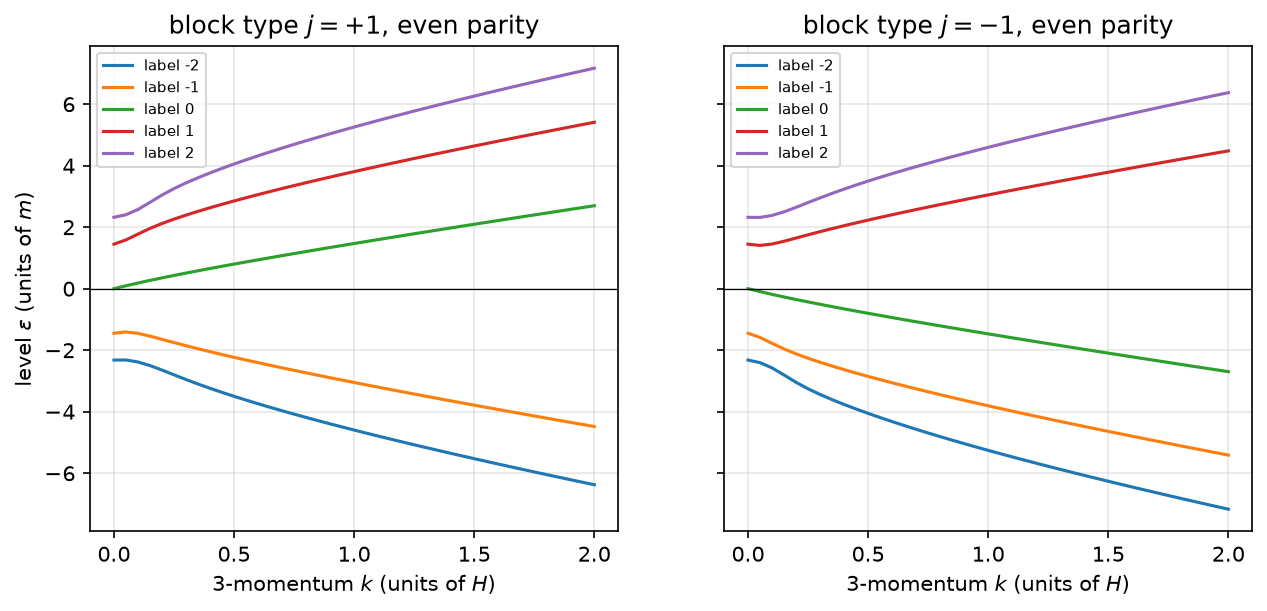

Figure 14c.4 saved as Revision/textbook/figures/14c_4_block_type_mirror.png


In [10]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.2), sharey=True)
for row, label in enumerate(fig_labels):
    left.plot(k_mirror, plus_curves[row], label=f"label {label}")
    right.plot(k_mirror, minus_curves[row], label=f"label {label}")
for ax, title in ((left, "block type $j = +1$"), (right, "block type $j = -1$")):
    ax.axhline(0.0, color="black", linewidth=0.6)
    ax.set_xlabel("3-momentum $k$ (units of $H$)")
    ax.set_title(title + ", even parity")
    ax.legend(fontsize=7, loc="upper left")
left.set_ylabel("level $\\varepsilon$ (units of $m$)")
save_figure(fig, "block_type_mirror",
            "The even-parity levels with labels $-2$ to $2$ against the "
            "3-momentum $k$ (units of $H$), slice 0, $m = 1$, $L = 3$; vertical "
            "axis the level in units of $m$. Left the blocks $j = +1$, right the "
            "blocks $j = -1$: each picture is the other one reflected in the line "
            "$\\varepsilon = 0$ (label $l$ goes to $-l$), the exact relation "
            "$h_{-1} = -h_{+1}$; the rising curve of the label 0 on the left is the "
            "brane band, the falling one on the right its sea partner.")

## 10. The tip condition does not matter for the band

For $k \ne 0$ an orbital is suppressed toward the tip like
$\exp(-k(\kappa(-L) - \kappa(y))/H)$ (the Revision record,
`boundaryConditions.tip`): the term $\kappa k\sigma_3$ grows toward the tip and
pushes the orbital away. So the level cannot depend much on the condition
imposed there. The next cell computes the brane band with the tip angles
$\theta = 0, 0.5, 1$ for $k = 0.25, 0.5, 1$ (the record `tip-angle.csv`) and
checks that the shift from $\theta = 0$ is below the suppression factor
$\exp(-k(e^{HL} - 1)/H)$ (the Rust check `free_tip_angle_insensitivity`); then
it computes the shifts for ten momenta from 0.1 to 1 for the figure.

In [11]:
tip_rows = read_csv(f"{SPECTRUM}/tip-angle.csv")
tip_k = np.array([0.25, 0.5, 1.0])
tip_levels = {th: levels(tip_k, 1.0, "even", 0, tip=th) for th in (0.0, 0.5, 1.0)}
suppression = np.exp(-tip_k * (math.exp(3.0) - 1.0))  # H = 1, L = 3
worst_tip, below = 0.0, True
for r in tip_rows:
    i_k = list(tip_k).index(float(r["k"]))
    mine = tip_levels[float(r["theta_tip"])][i_k]
    worst_tip = max(worst_tip, abs(mine - float(r["eps"])))
    shift = mine - tip_levels[0.0][i_k]
    below &= abs(shift) <= max(suppression[i_k], 1e-12)
check(len(tip_rows) == 9 and worst_tip < 1e-11 and below
      and record_check("free_tip_angle_insensitivity"),
      "the band levels equal tip-angle.csv; the shifts are below the suppression",
      record=f"{SPECTRUM}/tip-angle.csv and {RUST_REPORT}, check "
             "free_tip_angle_insensitivity")
k_tip = np.linspace(0.1, 1.0, 10)
shifts = {th: np.abs(levels(k_tip, 1.0, "even", 0, tip=th)
                     - levels(k_tip, 1.0, "even", 0, tip=0.0)) for th in (0.5, 1.0)}
for k_, s5, s10 in zip(k_tip, shifts[0.5], shifts[1.0]):
    say(f"k = {k_:.1f}: shift for theta = 0.5: {s5:.1e}, for theta = 1: {s10:.1e}")

PASS the band levels equal tip-angle.csv; the shifts are below the suppression
     reproduces Revision/kohn_sham/results/spectrum/tip-angle.csv and
    Revision/kohn_sham/reports/ks-rust-solver.json, check free_tip_angle_insensitivity
k = 0.1: shift for theta = 0.5: 4.6e-04, for theta = 1: 1.2e-03
k = 0.2: shift for theta = 0.5: 3.8e-05, for theta = 1: 1.2e-04
k = 0.3: shift for theta = 0.5: 1.8e-06, for theta = 1: 5.9e-06
k = 0.4: shift for theta = 0.5: 7.1e-08, for theta = 1: 2.4e-07
k = 0.5: shift for theta = 0.5: 2.5e-09, for theta = 1: 8.6e-09
k = 0.6: shift for theta = 0.5: 8.1e-11, for theta = 1: 2.8e-10
k = 0.7: shift for theta = 0.5: 2.6e-12, for theta = 1: 9.0e-12
k = 0.8: shift for theta = 0.5: 7.7e-14, for theta = 1: 2.7e-13
k = 0.9: shift for theta = 0.5: 2.2e-15, for theta = 1: 8.4e-15
k = 1.0: shift for theta = 0.5: 4.4e-16, for theta = 1: 0.0e+00


The next cell draws the shifts against $k$ on a logarithmic axis, together with
the suppression factor. Shifts below about $10^{-15}$ are rounding noise of the
floating-point numbers and are drawn at $10^{-16}$.

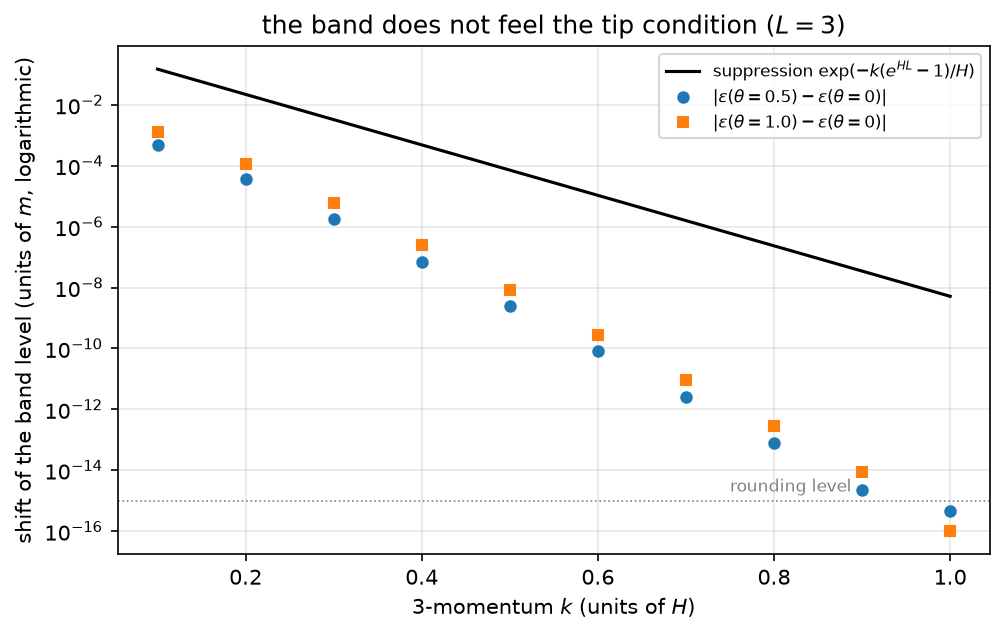

Figure 14c.5 saved as Revision/textbook/figures/14c_5_tip_insensitivity.png


In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))
k_line = np.linspace(0.1, 1.0, 91)
ax.semilogy(k_line, np.exp(-k_line * (math.exp(3.0) - 1.0)), color="black",
            label="suppression $\\exp(-k(e^{HL} - 1)/H)$")
for th, marker in ((0.5, "o"), (1.0, "s")):
    ax.semilogy(k_tip, np.maximum(shifts[th], 1e-16), marker, markersize=5,
                label=f"$|\\varepsilon(\\theta = {th}) - \\varepsilon(\\theta = 0)|$")
ax.axhline(1e-15, color="gray", linestyle=":", linewidth=0.8)
ax.annotate("rounding level", (0.75, 2e-15), fontsize=8, color="gray")
ax.set_xlabel("3-momentum $k$ (units of $H$)")
ax.set_ylabel("shift of the band level (units of $m$, logarithmic)")
ax.set_title("the band does not feel the tip condition ($L = 3$)")
ax.legend(fontsize=8)
save_figure(fig, "tip_insensitivity",
            "The change of the brane-band level when the tip condition "
            "$(1 - Q(\\theta))\\chi(-L) = 0$ is changed from $\\theta = 0$ to "
            "$\\theta = 0.5$ (circles) and $\\theta = 1$ (squares), against the "
            "3-momentum $k$ (units of $H$), for $m = 1$, $L = 3$, logarithmic "
            "vertical axis in units of $m$; every shift lies below the "
            "suppression factor $\\exp(-k(e^{HL} - 1)/H)$ (line) and from "
            "$k = 0.6$ on it is at the rounding level of the computer: the band "
            "lives at the brane and does not see the cutoff.")

## 11. Particles, degeneracies and closed shells

**Shells.** The lattice vectors $(n_1, n_2, n_3)$ with the same
$n^2 = n_1^2 + n_2^2 + n_3^2$ have the same $|k| = 0.25\sqrt{n^2}$; $r_3(n^2)$
counts them (the first values, checked against the Rust unit test, are
$r_3 = 1, 6, 12, 8, 6, 24, 24, 12, 30$ for $n^2 = 0, 1, 2, 3, 4, 5, 6, 8, 9$; no
vector has $n^2 = 7$). Each level of a block type then holds $4r_3(n^2)$ states.

**Particles (CONVENTION).** In each sector (shell, $j$, parity) the particle
levels are those with $\varepsilon > 0$ in the free problem, plus the $k = 0$
zero modes; the negative ones form the sea. Because $\Phi$ grows with
$\varepsilon$, the particle levels are exactly the labels $l \ge l_{\min}$, where
$l_{\min}$ is the first label whose target lies above $\Phi(0)$. The Rust check
`free_particle_branch_labels` verified this for all shells $n^2 \le 30$ and
found the level closest to zero (away from the zero modes) at $0.4307\,m$.

**Closed shells.** Filling the particle states from the bottom (the aufbau),
$N$ is a closed shell when it ends exactly at the end of a group of degenerate
levels (equal within $10^{-9}$). The Rust solver listed them up to
$\varepsilon = 1.6\,m$ at every slice (`closed-shells.csv`), and chose its
particle numbers by a rule: $N = 8$ (the zero modes), $N_{\rm large}$ = the
largest closed shell below the BULK EDGE (the lowest level not on the brane
band, the smaller of the odd label 0 and the even label 1 at $k = 0$), and
$N_{\rm mid}$ = the closed shell nearest to $N_{\rm large}/4$
(`parameters.json`). The next cell computes all of this for the slices 0 and
0.5. It takes about 20 seconds.

In [13]:
def shells(n2_max):
    """[(n2, r3)] for n2 = 0 ... n2_max with r3(n2) > 0 (counting lattice points)."""
    r = math.isqrt(n2_max) + 1
    count = [0] * (n2_max + 1)
    for x in range(-r, r + 1):
        for y_ in range(-r, r + 1):
            for z_ in range(-r, r + 1):
                s = x * x + y_ * y_ + z_ * z_
                if s <= n2_max:
                    count[s] += 1
    return [(n2, c) for n2, c in enumerate(count) if c > 0]


check(shells(9) == [(0, 1), (1, 6), (2, 12), (3, 8), (4, 6), (5, 24), (6, 24),
                    (8, 12), (9, 30)],
      "r3(n2) = 1, 6, 12, 8, 6, 24, 24, 12, 30 for n2 = 0, 1, 2, 3, 4, 5, 6, 8, 9")
SECTORS = [(1, "even"), (1, "odd"), (-1, "even"), (-1, "odd")]
SIGN = {1: "+1", -1: "-1"}


def lowest_particle_labels(pairs, a4):
    """l_min of each (n2, r3, j, parity) and Phi(0)."""
    k_ = np.array([0.25 * math.sqrt(n2) for n2, _, _, _ in pairs])
    j_ = np.array([float(j) for _, _, j, _ in pairs])
    par = np.array([p for _, _, _, p in pairs])
    phi0 = shoot(0.0, k_, j_, a4)
    offset = np.where(par == "even", 0.0, 0.5 * np.pi)
    l_min = np.floor((phi0 - offset) / np.pi).astype(int) + 1
    nearest = np.round((phi0 - offset) / np.pi).astype(int)
    zero_mode = (k_ == 0.0) & (np.abs(phi0 - offset - nearest * np.pi) < 1e-12)
    return np.where(zero_mode, nearest, l_min), phi0, offset, k_, j_, par


pairs30 = [(n2, r3, j, p) for n2, r3 in shells(30) for j, p in SECTORS]
l_min, phi0, offset, k30, j30, p30 = lowest_particle_labels(pairs30, 0.0)
e_first = levels(k30, j30, p30, l_min)
e_below = levels(k30, j30, p30, l_min - 1)
zero_k = k30 == 0.0
branch_ok = (np.all(e_below < 0.0)
             and np.all(e_first[zero_k & (p30 == "even")] == 0.0)
             and np.all(e_first[~(zero_k & (p30 == "even"))] > 0.0))
closest = float(min(np.min(e_first[~(zero_k & (p30 == "even"))]),
                    np.min(-e_below)))
report("level closest to zero away from the zero modes (n2 <= 30)",
       f"{closest:.4f}", "m")
check(branch_ok and f"{closest:.4f}" == "0.4307"
      and record_check("free_particle_branch_labels"),
      "particles are the labels l >= l_min in every sector (n2 <= 30)",
      record=f"{RUST_REPORT}, check free_particle_branch_labels")

PASS r3(n2) = 1, 6, 12, 8, 6, 24, 24, 12, 30 for n2 = 0, 1, 2, 3, 4, 5, 6, 8, 9
RESULT level closest to zero away from the zero modes (n2 <= 30) = 0.4307 m
PASS particles are the labels l >= l_min in every sector (n2 <= 30)
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    free_particle_branch_labels


The next cell builds the closed shells at the slices 0 and 0.5 as the Rust
solver does: for every shell (in the order of $n^2$) and sector it finds the
particle levels $l_{\min}, l_{\min} + 1, \dots$ up to $1.6\,m$; it stops at the
first shell $n^2 > 0$ that has no level below $1.6\,m$; it sorts all levels by
energy (and by name), groups levels that agree within $10^{-9}$, and adds up the
degeneracies $4r_3(n^2)$. Each level is named `n2:j:parity:label`. The table
must equal the record row by row (the numbers $N$, the names of the last group,
the energies to $10^{-11}$). Then it finds the bulk edge and the particle numbers
and compares them with `parameters.json`.

In [14]:
def closed_shells(a4, n2_max, e_max=1.6):
    """[(N, eps_last, eps_next, names)] of the free aufbau at the slice a4."""
    pairs = [(n2, r3, j, p) for n2, r3 in shells(n2_max) for j, p in SECTORS]
    l_next, _, _, k_, j_, par = lowest_particle_labels(pairs, a4)
    found_levels = []  # (energy, degeneracy, name, n2)
    active = np.arange(len(pairs))
    while len(active) > 0:  # one more label in every sector that is still open
        e_ = levels(k_[active], j_[active], par[active], l_next[active], a4=a4)
        keep = e_ <= e_max
        for index, energy in zip(active[keep], e_[keep]):
            n2, r3, j, p = pairs[index]
            found_levels.append((float(energy), 4.0 * r3,
                                 f"{n2}:{SIGN[j]}:{p}:{l_next[index]}", n2))
        active = active[keep]
        l_next[active] += 1
    with_levels = {n2 for _, _, _, n2 in found_levels}
    stop = next(n2 for n2, _ in shells(n2_max) if n2 > 0 and n2 not in with_levels)
    found_levels = [lev for lev in found_levels if lev[3] < stop]
    found_levels.sort(key=lambda lev: (lev[0], lev[2]))
    table, total, i = [], 0.0, 0
    while i < len(found_levels):  # group the degenerate levels
        e0, group, names = found_levels[i][0], 0.0, []
        while i < len(found_levels) and found_levels[i][0] - e0 <= 1e-9:
            group += found_levels[i][1]
            names.append(found_levels[i][2])
            i += 1
        total += group
        following = found_levels[i][0] if i < len(found_levels) else float("nan")
        table.append((int(total), e0, following, ";".join(names)))
    return table, stop


agree = True
tables = {}
for a_, n2_max in ((0.0, 40), (0.5, 80)):
    table, stop = closed_shells(a_, n2_max)
    tables[a_] = table
    mine_rows = [r for r in shells_record if float(r["a4"]) == a_]
    same = len(table) == len(mine_rows) and all(
        int(r["N_closed"]) == t[0] and r["levels_of_the_last_group"] == t[3]
        and abs(float(r["eps_last_filled"]) - t[1]) < 1e-11
        for r, t in zip(mine_rows, table))
    agree &= same and stop < n2_max
    say(f"slice {a_}: {len(table)} closed shells up to 1.6 m, the first shell "
        f"without a level below 1.6 m is n2 = {stop}; equal to the record: {same}")
check(agree, "the closed shells of the slices 0 and 0.5 equal the record row by row",
      record=f"{SPECTRUM}/closed-shells.csv, rows a4 = 0 and 0.5")
say("slice 0: N = " + ", ".join(str(t[0]) for t in tables[0.0]))
bulk_edge = float(min(levels(0.0, 1.0, "odd", 0), levels(0.0, 1.0, "even", 1)))
below_edge = [t for t in tables[0.0] if t[1] < bulk_edge and t[2] - t[1] > 1e-6]
N_large = below_edge[-1][0]
N_mid = min((t[0] for t in below_edge if t[0] >= 8),
            key=lambda n: abs(n - N_large / 4))
parameters = json.loads(repository_file("Revision/kohn_sham/results/parameters.json")
                        .read_text(encoding="utf-8"))
numbers = parameters["particleNumbers"]
report("bulk edge", f"{bulk_edge:.12f}", "m")
report("particle numbers N", f"8, {N_mid}, {N_large}")
check(abs(bulk_edge - numbers["bulkEdge"]) < 1e-12 and N_large == 688
      and N_mid == 136 and numbers["values"] == [8.0, 136.0, 688.0],
      "the bulk edge 1.2922928281 and the particle numbers 8, 136, 688",
      record="Revision/kohn_sham/results/parameters.json, particleNumbers")

slice 0.0: 22 closed shells up to 1.6 m, the first shell without a level below 1.6 m is
    n2 = 20; equal to the record: True
slice 0.5: 55 closed shells up to 1.6 m, the first shell without a level below 1.6 m is
    n2 = 53; equal to the record: True
PASS the closed shells of the slices 0 and 0.5 equal the record row by row
     reproduces Revision/kohn_sham/results/spectrum/closed-shells.csv, rows a4 = 0 and
    0.5
slice 0: N = 8, 32, 80, 112, 136, 232, 328, 376, 496, 592, 688, 696, 728, 824, 1016,
    1040, 1048, 1072, 1264, 1408, 1456, 1552
RESULT bulk edge = 1.292292828069 m
RESULT particle numbers N = 8, 136, 688
PASS the bulk edge 1.2922928281 and the particle numbers 8, 136, 688
     reproduces Revision/kohn_sham/results/parameters.json, particleNumbers


The next cell draws the aufbau as a staircase: the number $N$ of filled
particle states against the energy of the last filled level, at the slices 0 and
0.5, with the bulk edge and the three particle numbers of the Revision runs
marked. At the later slice the redshifted band holds many more states below the
same energy.

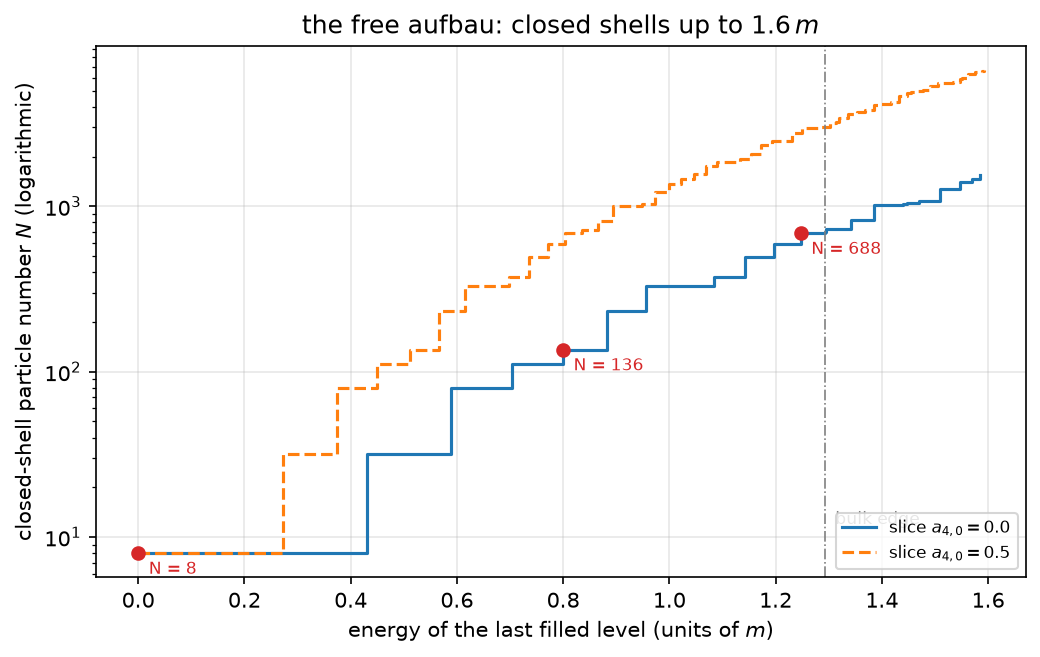

Figure 14c.6 saved as Revision/textbook/figures/14c_6_closed_shells.png


In [15]:
fig, ax = plt.subplots(figsize=(8.0, 4.6))
for a_, style in ((0.0, "-"), (0.5, "--")):
    energies = [t[1] for t in tables[a_]]
    counts = [t[0] for t in tables[a_]]
    ax.step(energies, counts, style, where="post",
            label=f"slice $a_{{4,0}} = {a_}$")
ax.axvline(bulk_edge, color="gray", linestyle="-.", linewidth=0.8)
ax.annotate("bulk edge", (bulk_edge + 0.02, 12), fontsize=8, color="gray")
last_filled = {t[0]: t[1] for t in tables[0.0]}  # N -> its last filled level
for n_ in (8, N_mid, N_large):
    t_ = last_filled[n_]
    ax.plot([t_], [n_], "o", color="C3")
    ax.annotate(f"N = {n_}", (t_ + 0.02, n_ * 0.75), fontsize=8, color="C3")
ax.set_yscale("log")
ax.set_xlabel("energy of the last filled level (units of $m$)")
ax.set_ylabel("closed-shell particle number $N$ (logarithmic)")
ax.set_title("the free aufbau: closed shells up to $1.6\\,m$")
ax.legend(fontsize=8, loc="lower right")
save_figure(fig, "closed_shells",
            "The closed shells of the free aufbau: the particle number $N$ "
            "(logarithmic axis) against the energy of the last filled level "
            "(units of $m$), at the slices $a_{4,0} = 0$ (solid) and $0.5$ "
            "(dashed), for $m = 1$, $L = 3$, $\\Delta k = 0.25$. Each step is one "
            "group of degenerate levels; the red dots mark the particle numbers "
            "$N = 8$ (the zero modes), $136$ and $688$ of the Revision runs, the "
            "last closed shells below the bulk edge $1.2923\\,m$ (dash-dotted) "
            "being $688$; at the later slice the redshifted brane band holds "
            "many more particles below the same energy.")

## 12. The last check

The last cell checks that the six figure files exist and prints the number of
checks that passed.

In [16]:
figure_names = ["14c_1_band_structure.png", "14c_2_band_slope.png",
                "14c_3_band_redshift.png", "14c_4_block_type_mirror.png",
                "14c_5_tip_insensitivity.png", "14c_6_closed_shells.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "all six figure files of this notebook exist")
all_checks_passed()

PASS all six figure files of this notebook exist
ALL 15 CHECKS PASSED (notebook 14c)


## 13. What this notebook showed

- The eight zero modes become the brane band when the 3-momentum is switched
  on; its slope at $k = 0$ is $c = e^{-a_{4,0}}\frac{2M}{2M - H}\frac{1 -
  e^{-(2M-H)L}}{1 - e^{-2ML}}$, $1.9051482536$ for $M = H = 1$, $L = 3$ (PROVED
  by the Hellmann-Feynman rule; COMPUTED numerically at all five slices; the
  values reproduce the Rust solver's records).
- Along the PRESCRIBED deflating history every level obeys the exact rescaling
  identity $\varepsilon(k, a_{4,0}) = \varepsilon(k e^{-a_{4,0}}, 0)$: the band
  is redshifted, and the gap of the free $N = 8$ state falls from $0.4307\,m$ at
  $a_{4,0} = 0$ to $0.0642\,m$ at $a_{4,0} = 2$.
- The two block types have mirrored spectra, $\mathrm{spec}\,h_{-1} =
  -\mathrm{spec}\,h_{+1}$, and $\sigma_3$ maps $(j, k)$ to $(-j, -k)$.
- The band lives at the brane: changing the tip condition shifts it by less than
  $\exp(-k(e^{HL} - 1)/H)$.
- With the CONVENTION that the positive free levels and the zero modes are
  particle levels (its justification is OPEN), the free aufbau has the closed
  shells $8, 32, 80, 112, 136, \dots, 688$ below the bulk edge $1.2923\,m$; the
  Revision runs use $N = 8, 136, 688$ (reproduced from the rule).
- ASSUMED: the Z2 mirror brane. CHOSEN: the regular tip at $L = 3$.